In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# for path building
from pathlib import Path

In [30]:
# load project modules
from song_recommender.paths import *
from song_recommender.data.indexer import *

# Metadata EDA:

In this notebook, we look at the metadata related to our audio dataset. 

In [31]:
df = pd.read_pickle(f'{DATA_DIR}/metadata_raw.pkl')
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,crude_genre,duration_min,clip_duration
10133,TRUJRZQ128F427EDFB,Am I Wrong,Nico & Vinz,https://p.scdn.co/mp3-preview/20c92c53b6a5c0a1...,08SxltHeEkQqgx5foDRRqO,pop,Blues,2013,249520,0.719,...,0.0346,0.183000,0.000003,0.0979,0.794,119.935,4,pop,4.158667,30.000000
10099,TRHZOXJ12903CA71C6,The Darkest Places,MxPx,https://p.scdn.co/mp3-preview/2b9d8651251de649...,08i9oFejJHqANJjbZqXEII,"punk, punk_rock",Punk,2005,155240,0.452,...,0.0861,0.000010,0.001140,0.1150,0.355,102.791,4,rock,2.587333,30.000045
4742,TROWNFJ12903CCF745,Chain Hang Low,Jibbs,https://p.scdn.co/mp3-preview/41fdc882915407cf...,0bEWzalbBcEsPOiXKWbk1g,"rap, hip_hop",NaN,2006,207586,0.792,...,0.2620,0.025900,0.000128,0.1140,0.778,157.147,4,hip_hop,3.459767,10.000000
3816,TRLTGWG128F92F148B,"Assurance, Closure",Artist vs. Poet,https://p.scdn.co/mp3-preview/3b33874b1f600ed7...,102r5VaEMIzcuajckf0oYt,"electronic, pop, alternative_rock, punk",Rock,2008,171800,0.404,...,0.0932,0.000741,0.000000,0.2140,0.554,163.906,4,rock,2.863333,10.000000
8176,TRRQDBC128F428A43E,Nothing Is Easy,Jethro Tull,https://p.scdn.co/mp3-preview/7e18a0d6fdf170a7...,0hU6ShAlZsiE8vpgt7BEpU,"classic_rock, progressive_rock, 60s",Rock,1984,262973,0.436,...,0.0612,0.403000,0.014000,0.1320,0.679,110.752,3,rock,4.382883,10.000000


## Feature analysis

**fill this out**

In [32]:
df.columns

Index(['track_id', 'name', 'artist', 'spotify_preview_url', 'spotify_id',
       'tags', 'genre', 'year', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'crude_genre',
       'duration_min', 'clip_duration'],
      dtype='object')

## Feature Engineering

We add a `decade` feature.

In [33]:
# add decade feature
df['decade'] = df['year'] - (df['year'] % 10)
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,crude_genre,duration_min,clip_duration,decade
6751,TRBULGO12903CB8D55,Braablick blev hun vaer,Ulver,https://p.scdn.co/mp3-preview/168b1f4056452b42...,7kMAKXE2gBglYIlqojfeJy,black_metal,NaN,1994,464160,0.220,...,0.00275,0.738,0.1620,0.0357,167.889,4,metal,7.736000,10.0,1990
7386,TRLWEUJ128F92D9834,Always Something There To Remind Me,Naked Eyes,https://p.scdn.co/mp3-preview/69b6d121edda0728...,0AsMjJVCZQczuvQbqnRVuM,"80s, new_wave, synthpop, cover",NaN,2011,222040,0.608,...,0.18800,0.000,0.4690,0.7270,149.281,4,pop,3.700667,10.0,2010
5545,TRCXYYC128F930F284,I Robot,The Alan Parsons Project,https://p.scdn.co/mp3-preview/1f0681eff417662d...,0jlMoXeadr4XHdRBwuTyGp,"rock, classic_rock, instrumental, 80s, progres...",Rock,2007,315120,0.618,...,0.44600,0.764,0.2350,0.7460,90.570,4,rock,5.252000,10.0,2000
7092,TRIMKPV128F92F3FB4,Free Your Mind,En Vogue,https://p.scdn.co/mp3-preview/5c70dc1c17c9b94e...,0E32ssQUysRfsgzX0tvOIk,"pop, female_vocalists, dance, soul, 90s, funk,...",NaN,2002,228306,0.683,...,0.00850,0.000,0.1090,0.6000,101.970,4,pop,3.805100,10.0,2000
4638,TRADIFS128F92F5AD3,To All The Girls,Beastie Boys,https://p.scdn.co/mp3-preview/1dec9f6d99a9a62e...,53XJePCN8f7YUqIeVr2HjQ,"80s, chillout, rap, hip_hop, funk",Pop,1989,89426,0.417,...,0.65800,0.854,0.0965,0.2180,74.017,4,hip_hop,1.490433,10.0,1980


### Task 1: Tag analysis

We accomplish this by string splitting the `tag` column.

In [34]:
# tags need split to identify actual value counts
df['tags'].value_counts()

tags
black_metal                                       409
rap, hip_hop                                      261
death_metal                                       175
death_metal, melodic_death_metal                  148
punk, punk_rock                                   126
                                                 ... 
indie, pop, singer_songwriter, acoustic, chill      1
country, folk                                       1
folk, male_vocalists, beautiful, 00s                1
pop, female_vocalists, 70s, oldies                  1
metalcore, progressive_metal                        1
Name: count, Length: 5856, dtype: int64

In [35]:
# create tag counter
from collections import Counter

tag_list = []

for index, tags in df['tags'].items():
    tags = tags.replace(' ','')
    tag_list += tags.split(',')

tag_counts = Counter(tag_list)

In [36]:
tag_counts.most_common()

[('rock', 2242),
 ('indie', 1272),
 ('death_metal', 1219),
 ('classic_rock', 1180),
 ('folk', 1105),
 ('punk', 1079),
 ('instrumental', 1064),
 ('80s', 1037),
 ('black_metal', 1030),
 ('electronic', 1025),
 ('ambient', 1017),
 ('singer_songwriter', 968),
 ('hip_hop', 958),
 ('progressive_rock', 923),
 ('alternative', 922),
 ('experimental', 908),
 ('hard_rock', 808),
 ('punk_rock', 777),
 ('70s', 761),
 ('rap', 735),
 ('heavy_metal', 732),
 ('acoustic', 710),
 ('chillout', 681),
 ('indie_rock', 641),
 ('pop', 638),
 ('mellow', 629),
 ('melodic_death_metal', 593),
 ('dance', 587),
 ('chill', 564),
 ('90s', 562),
 ('female_vocalists', 561),
 ('alternative_rock', 556),
 ('00s', 555),
 ('beautiful', 530),
 ('hardcore', 520),
 ('progressive_metal', 509),
 ('psychedelic', 504),
 ('metal', 495),
 ('american', 485),
 ('metalcore', 452),
 ('love', 438),
 ('british', 433),
 ('60s', 430),
 ('new_wave', 413),
 ('indie_pop', 410),
 ('emo', 395),
 ('thrash_metal', 394),
 ('piano', 389),
 ('downtempo

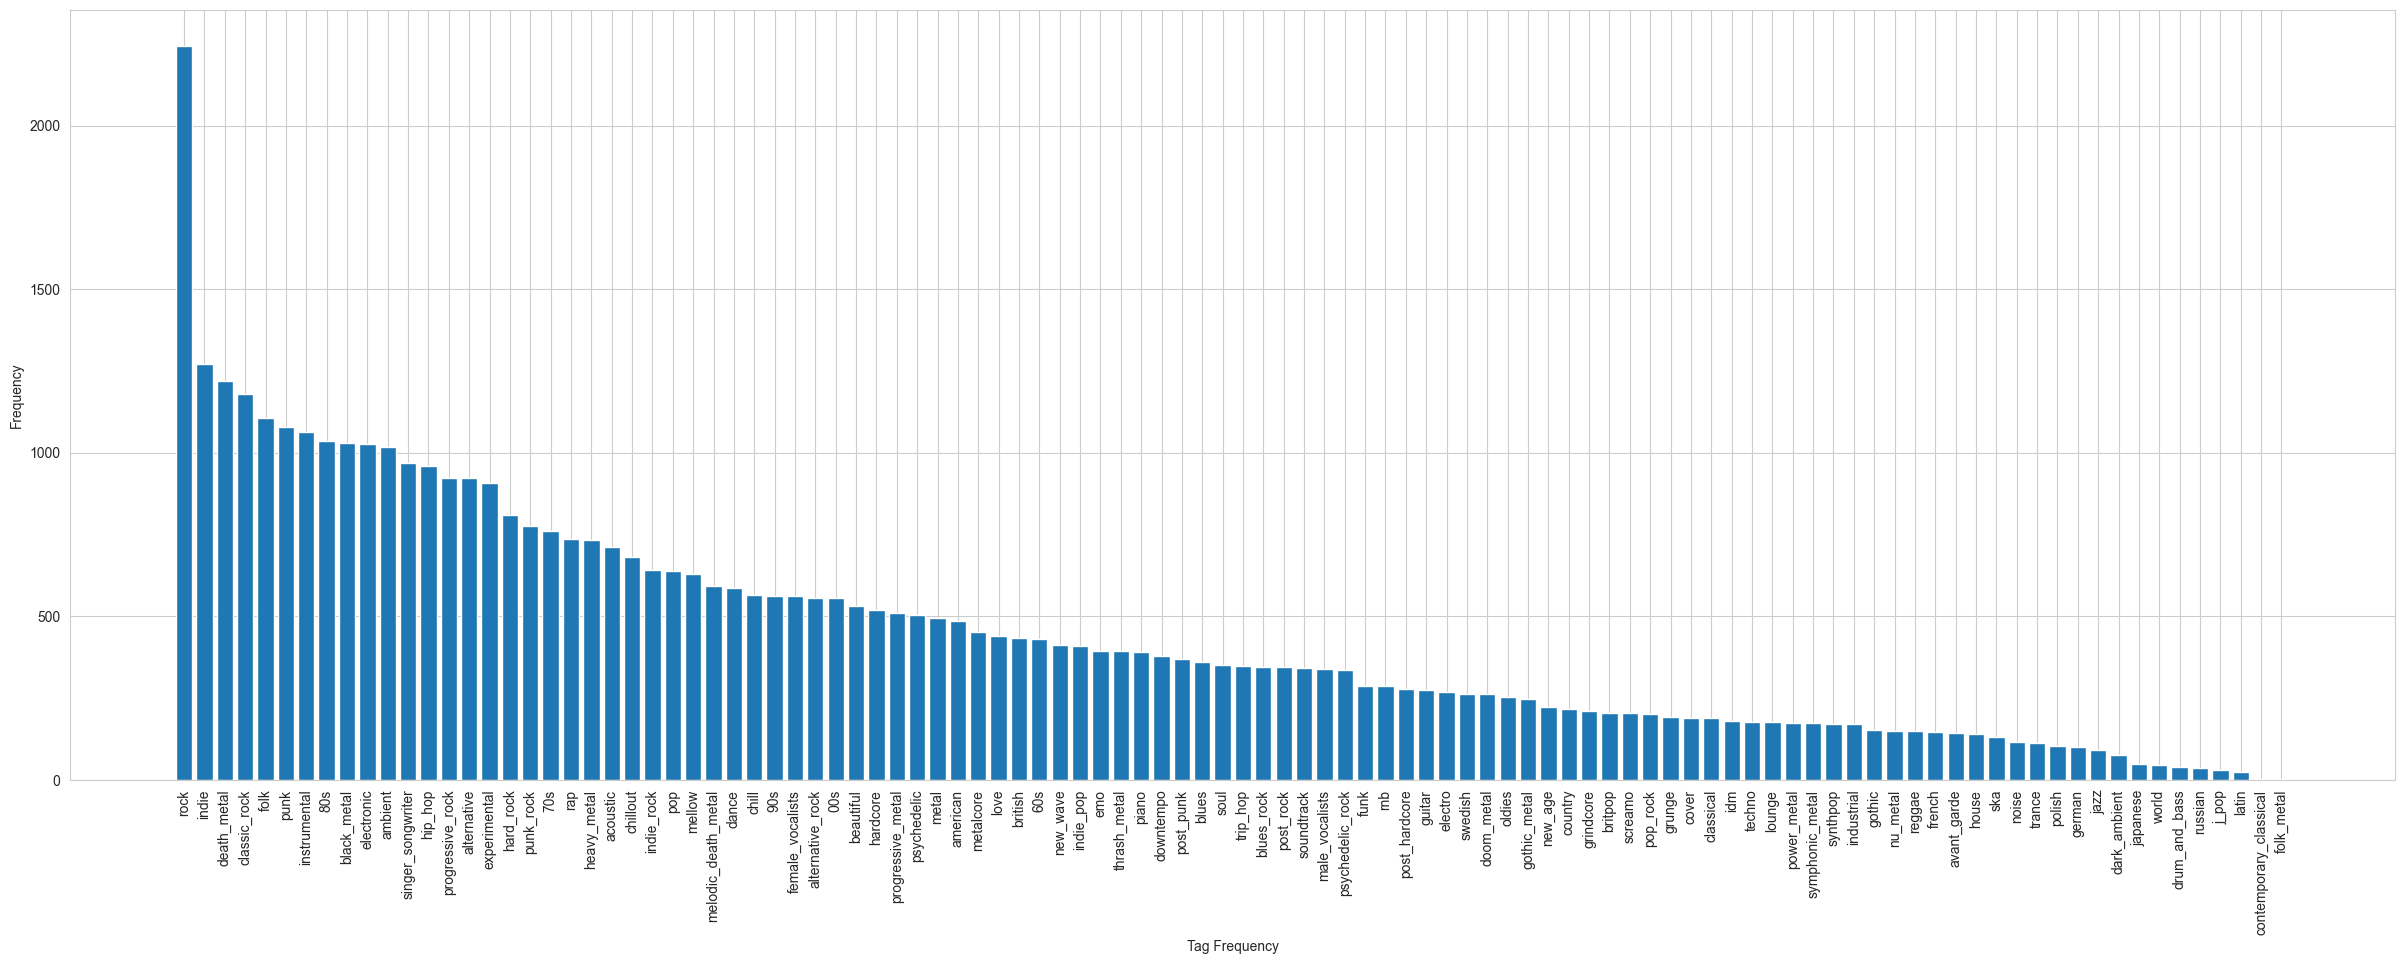

In [37]:
# ordered tag count histogram
plt.figure(figsize=(30,10))
plt.bar([tag[0] for tag in tag_counts.most_common()], [tag[1] for tag in tag_counts.most_common()])
plt.xlabel('Tag Frequency')
plt.xticks(rotation='vertical')
plt.ylabel('Frequency')
plt.show()

### Task 2: Estimated genre distribution

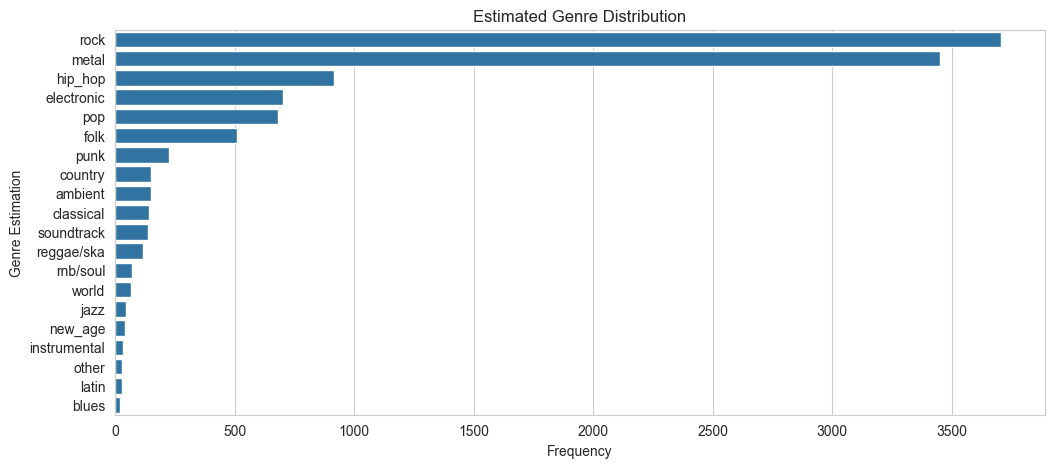

In [38]:
plt.figure(figsize=(12,5))
sns.barplot(data = df['crude_genre'].value_counts(), orient='h')
plt.ylabel('Genre Estimation')
plt.xlabel('Frequency')
plt.title("Estimated Genre Distribution")
plt.show()

In [39]:
df['crude_genre'].value_counts()

crude_genre
rock            3706
metal           3452
hip_hop          917
electronic       701
pop              681
folk             510
punk             227
country          152
ambient          150
classical        144
soundtrack       139
reggae/ska       116
rnb/soul          71
world             66
jazz              48
new_age           43
instrumental      33
other             31
latin             31
blues             21
Name: count, dtype: int64

The dataset is very rock/metal biased. What percentage is rock or metal? **Approximately 63.7% rock or metal.**

In [40]:
df['crude_genre'].value_counts()[:2].sum()/len(df)

np.float64(0.6368894029717946)

### Task 3. Year and Decade Distribution

The mean year is 2003 with standard deviation 9.6 years. The middle 50% of the dataset is between 2000 and 2009. 

In [41]:
df['year'].describe()

count    11239.000000
mean      2003.070914
std          9.647030
min       1933.000000
25%       2000.000000
50%       2006.000000
75%       2009.000000
max       2022.000000
Name: year, dtype: float64

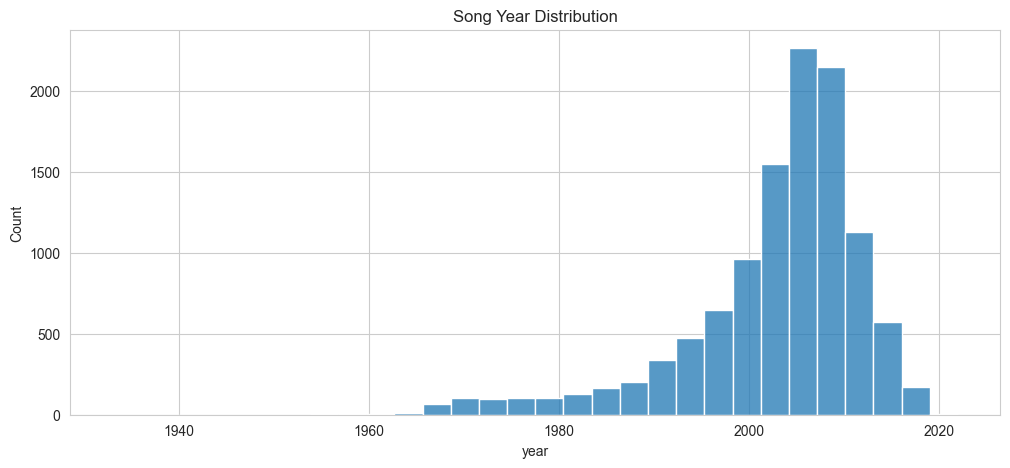

In [42]:
plt.figure(figsize=(12,5))
sns.histplot(df['year'], bins=30)
plt.title("Song Year Distribution")
plt.show()

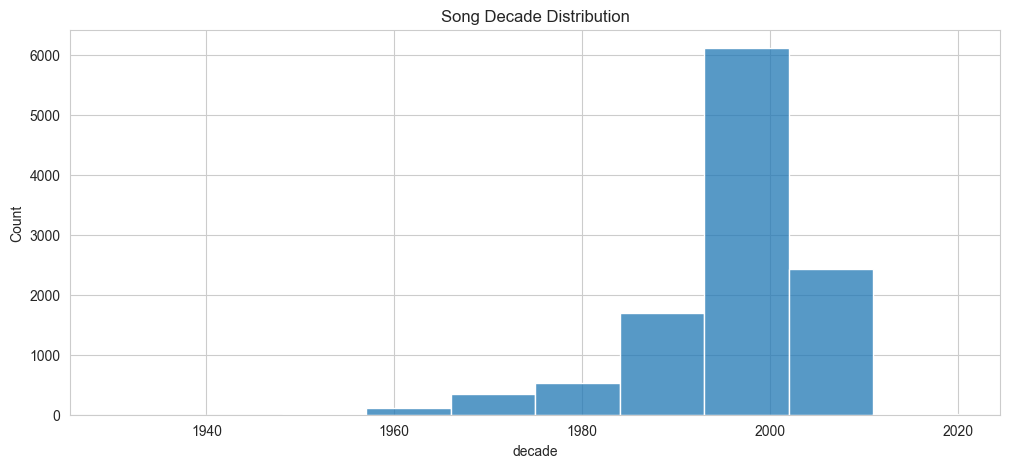

In [43]:
plt.figure(figsize=(12,5))
sns.histplot(df['decade'], bins=10)
plt.title("Song Decade Distribution")
plt.show()

In [44]:
df['decade'].value_counts()

decade
2000    6111
2010    2435
1990    1694
1980     528
1970     350
1960     108
2020       6
1950       6
1930       1
Name: count, dtype: int64

Approximately 76.0% of the tracks come from the decade 2000 or 2010.

In [45]:
df['decade'].value_counts()[:2].sum()/len(df)

np.float64(0.7603879348696503)

### Task 4: Artist analysis

In [164]:
artist_counts = Counter(df['artist'].str.lower().str.replace(' ',''))

In [165]:
# number of unique artists
len(artist_counts)

2881

In [166]:
# percentage of artists with more than 1 track in the dataframe
len([(artist, count) for artist, count in artist_counts.items() if count > 1]) / len(artist_counts)

0.5019090593543908

In [167]:
# percentage of artists with more than 2
len([(artist, count) for artist, count in artist_counts.items() if count > 2]) / len(artist_counts)

0.3554321416174939

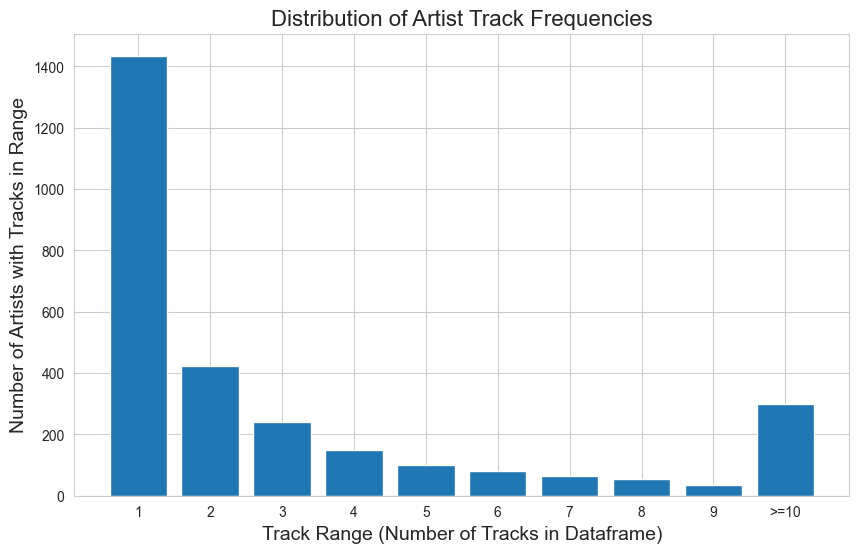

In [168]:
bin_counts = {str(i): 0 for i in range(1, 10)}
bin_counts['>=10'] = 0

for value in artist_counts.values():
    if value >= 10:
        bin_counts['>=10'] += 1
    elif 1 <= value <= 9:
        bin_counts[str(value)] += 1

labels = list(bin_counts.keys())
frequencies = list(bin_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, frequencies)
plt.xlabel("Track Range (Number of Tracks in Dataframe)", fontsize=14)
plt.ylabel("Number of Artists with Tracks in Range", fontsize=14)
plt.title("Distribution of Artist Track Frequencies", fontsize=16)

plt.show()

#### Verifying unique artists:

We verify that there are no duplicate artists due to characters in the string, e.g., additional spaces or special characters.

In [93]:
pattern = r'[^a-zA-Z0-9]'
# just special characters [^a-zA-Z0-9\s]
# special characters and spaces [^a-zA-Z0-9]

In [156]:
artist_df = df[['artist']].drop_duplicates()
artist_df['normalized_artist'] = df['artist'].str.lower().str.replace(pattern,'',regex = True)
artist_df

,artist,normalized_artist
0,Rush,rush
1,Queen,queen
2,Cream,cream
3,Creedence Clearwater Revival,creedenceclearwaterrevival
4,Lynyrd Skynyrd,lynyrdskynyrd
...,...,...
11229,Bing Crosby,bingcrosby
11230,Jimmy Durante,jimmydurante
11231,Carpenters,carpenters
11236,Feed Her to the Sharks,feedhertothesharks


In [157]:
for index, artist in artist_df['normalized_artist'].items():
    matches = artist_df.loc[artist_df['normalized_artist'] == artist]
    if len(matches) > 1:
        display(matches)

,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


,artist,normalized_artist
5512,Արամ Խաչատրյան,
7242,!!!,
10912,倖田來未,
11172,عمر دياب,


Special character only artists are being considered the same. Careful using regex.

In [158]:
artist_df = df[['artist']].drop_duplicates()
artist_df['normalized_artist'] = df['artist'].str.lower().str.replace(' ','')

for index, artist in artist_df['normalized_artist'].items():
    matches = artist_df.loc[artist_df['normalized_artist'] == artist]
    if len(matches) > 1:
        display(matches)

## Conclusion:

There is a strong bias in the tracks to rock or metal released between 2000 and 2020. 